# E-commerce Delivery Time Prediction — Model Training

**Business problem.** An e-commerce operator wants to predict how many hours a
delivery will take based on order and logistics attributes (product category,
shipping mode, order value, package weight, warehouse distance, number of
items, warehouse processing time, courier load, and traffic conditions).
An accurate estimate lets ops teams set customer expectations, staff couriers,
and flag orders that are likely to run late.

**Target variable:** `Delivery_Time_Hours` (numeric, hours)
**Identifier (excluded from modeling):** `Order ID`
**Numerical predictors:** Order Value, Package_Weight_Kg, Warehouse Distance Km,
Items in Order, Warehouse_Processing_Hours, Courier_Load_Index, Traffic Index
**Categorical predictors (nominal):** Product_Category, Shipping_Mode

This notebook works through **Part A — data preparation and linear
regression assumption checks** in order (diagnosis + corrective action for
each), then **Part B — model build & evaluation**, and **Part C — saving the
trained pipeline**.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor, OLSInfluence

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:
df = pd.read_csv("data.csv")
print("Shape:", df.shape)
df.head()

Shape: (2500, 11)


,Order ID,Product_Category,Shipping_Mode,Order Value,Package_Weight_Kg,Warehouse Distance Km,Items in Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic Index,Delivery_Time_Hours
0,ORD-10001,Office Supplies,Standard,73.58,3.3,253,5,9.8,0.77,0.93,14.3
1,ORD-10002,Books,Express,69.51,1.8,253,6,3.1,1.18,1.52,10.7
2,ORD-10003,Apparel,Standard,202.12,0.3,431,1,15.6,0.84,1.01,24.7
3,ORD-10004,Toys & Games,Standard,95.15,3.0,520,2,6.4,1.25,1.60,32.4
4,ORD-10005,Health & Beauty,Express,109.78,0.8,466,3,4.7,0.91,1.09,12.4


## Step 1 — Data quality: missing values, duplicates, impossible values, inconsistent labels

In [3]:
TARGET = "Delivery_Time_Hours"
ID_COL = "Order ID"
NUM_COLS = ["Order Value", "Package_Weight_Kg", "Warehouse Distance Km", "Items in Order",
            "Warehouse_Processing_Hours", "Courier_Load_Index", "Traffic Index"]
CAT_COLS = ["Product_Category", "Shipping_Mode"]

print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
Order ID                      0
Product_Category              0
Shipping_Mode                 0
Order Value                   0
Package_Weight_Kg             0
Warehouse Distance Km         0
Items in Order                0
Warehouse_Processing_Hours    0
Courier_Load_Index            0
Traffic Index                 0
Delivery_Time_Hours           0
dtype: int64


In [4]:
print("Fully duplicated rows:", df.duplicated().sum())
print("Duplicated Order IDs:", df[ID_COL].duplicated().sum())

Fully duplicated rows: 0
Duplicated Order IDs: 0


In [5]:
# Impossible / out-of-range values
issues = {
    "negative Order Value": (df["Order Value"] < 0).sum(),
    "negative Package_Weight_Kg": (df["Package_Weight_Kg"] < 0).sum(),
    "negative Warehouse Distance Km": (df["Warehouse Distance Km"] < 0).sum(),
    "Items in Order < 1": (df["Items in Order"] < 1).sum(),
    "negative Warehouse_Processing_Hours": (df["Warehouse_Processing_Hours"] < 0).sum(),
    "Courier_Load_Index <= 0": (df["Courier_Load_Index"] <= 0).sum(),
    "Traffic Index <= 0": (df["Traffic Index"] <= 0).sum(),
    "Delivery_Time_Hours <= 0": (df[TARGET] <= 0).sum(),
}
for k, v in issues.items():
    print(f"{k}: {v}")

negative Order Value: 0
negative Package_Weight_Kg: 0
negative Warehouse Distance Km: 0
Items in Order < 1: 0
negative Warehouse_Processing_Hours: 0
Courier_Load_Index <= 0: 0
Traffic Index <= 0: 0
Delivery_Time_Hours <= 0: 0


In [6]:
# Inconsistent category labels (case/whitespace variants that should map to one category)
for col in CAT_COLS:
    print(f"--- {col} ---")
    print(sorted(df[col].unique()))
    # normalised (stripped + title-cased) version, to reveal near-duplicate labels
    normed = df[col].str.strip().str.title()
    mismatches = (normed != df[col]).sum()
    print(f"Rows whose label changes after strip/title-case normalisation: {mismatches}")
    print()

--- Product_Category ---
['Apparel', 'Books', 'Electronics', 'Health & Beauty', 'Home & Kitchen', 'Office Supplies', 'Sports & Outdoors', 'Toys & Games']
Rows whose label changes after strip/title-case normalisation: 0

--- Shipping_Mode ---
['Economy', 'Express', 'Same Day', 'Standard']
Rows whose label changes after strip/title-case normalisation: 0



**Diagnosis.** This dataset (2,500 rows) has **no missing values**, **no fully
duplicated rows**, and **no duplicated `Order ID`s**. All numeric predictors
and the target are within valid ranges (no negative weights/distances, no
zero/negative item counts, no non-positive delivery times). `Product_Category`
(8 clean labels) and `Shipping_Mode` (4 clean labels: Standard, Express,
Economy, Same Day) show no case, whitespace, or spelling inconsistencies.

**Corrective action.** None required for missing values, duplicates, or
invalid ranges — the checks above are kept in the notebook as a permanent
audit step so that if the underlying data source changes (e.g. a new export
introduces nulls or a stray negative distance), the pipeline fails loudly
here rather than silently degrading the model. As a defensive measure we
still apply a light "just in case" cleaning step below (drop exact
duplicates, drop impossible rows, strip/title-case the two category
columns) so the notebook is robust to future data refreshes.


In [7]:
df_clean = df.copy()
df_clean = df_clean.drop_duplicates()
for col in CAT_COLS:
    df_clean[col] = df_clean[col].str.strip().str.title()

valid_mask = (
    (df_clean["Order Value"] >= 0)
    & (df_clean["Package_Weight_Kg"] >= 0)
    & (df_clean["Warehouse Distance Km"] >= 0)
    & (df_clean["Items in Order"] >= 1)
    & (df_clean["Warehouse_Processing_Hours"] >= 0)
    & (df_clean["Courier_Load_Index"] > 0)
    & (df_clean["Traffic Index"] > 0)
    & (df_clean[TARGET] > 0)
)
print("Rows removed by validity filter:", (~valid_mask).sum())
df_clean = df_clean.loc[valid_mask].reset_index(drop=True)
print("Rows remaining:", len(df_clean))

Rows removed by validity filter: 0
Rows remaining: 2500


## Step 2 — Target / feature understanding

- **Target:** `Delivery_Time_Hours` (continuous, hours)
- **Excluded identifier:** `Order ID` (unique per row, carries no predictive
  signal — including it would let the model "memorise" the training set)
- **Numerical predictors (7):** Order Value, Package_Weight_Kg, Warehouse
  Distance Km, Items in Order, Warehouse_Processing_Hours, Courier_Load_Index,
  Traffic Index
- **Categorical predictors (2, nominal):** Product_Category, Shipping_Mode —
  these have no natural ordering, so they must be one-hot encoded rather than
  label-encoded (Step 9).


In [8]:
df_clean[NUM_COLS + [TARGET]].describe().T

,count,mean,std,min,25%,50%,75%,max
Order Value,2500.0,150.797728,165.123950,12.15,53.01,90.250,181.435,867.57
Package_Weight_Kg,2500.0,3.051040,2.643738,0.20,1.00,2.500,3.800,12.10
Warehouse Distance Km,2500.0,522.624800,331.892223,11.00,252.75,482.500,758.250,1416.00
Items in Order,2500.0,3.500000,1.708791,1.00,2.00,3.500,5.000,6.00
Warehouse_Processing_Hours,2500.0,8.539640,5.398827,0.90,4.10,7.600,12.600,24.00
Courier_Load_Index,2500.0,1.069700,0.216531,0.70,0.88,1.070,1.260,1.44
Traffic Index,2500.0,1.395040,0.317527,0.85,1.12,1.395,1.670,1.94
Delivery_Time_Hours,2500.0,29.384640,22.801061,1.50,12.60,23.500,39.525,160.60


## Step 3 — Linearity: target vs. each numerical predictor

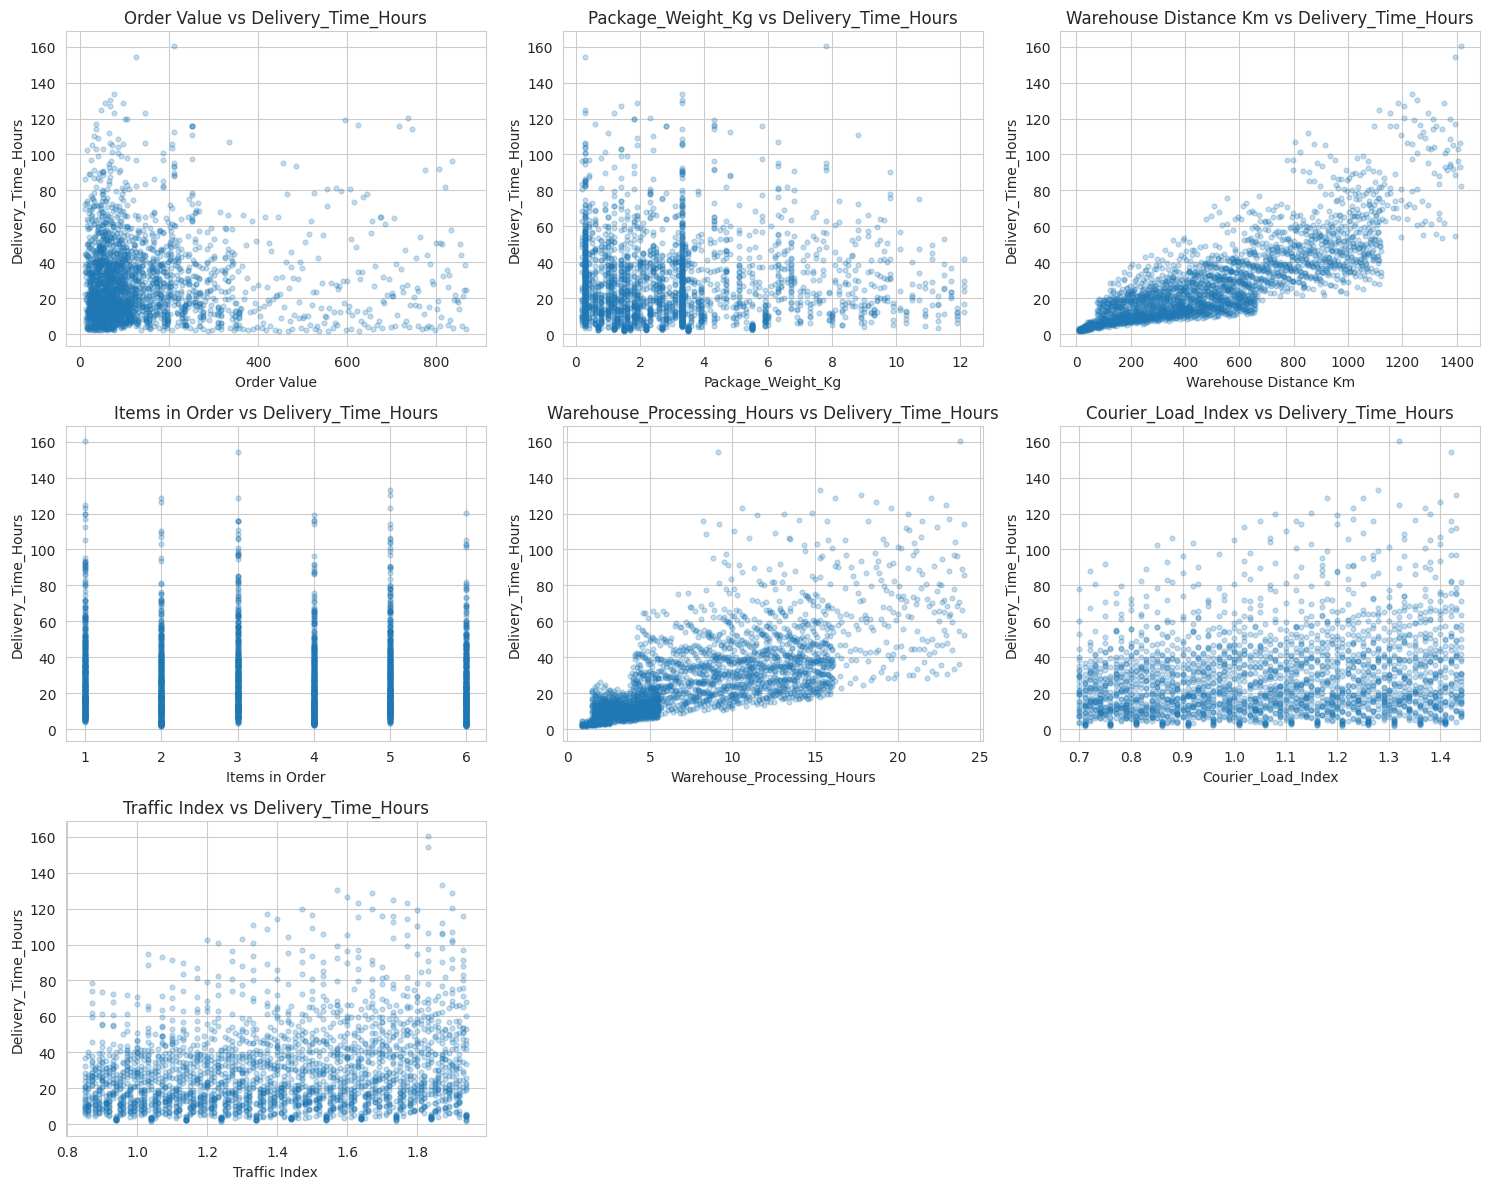

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    axes[i].scatter(df_clean[col], df_clean[TARGET], alpha=0.25, s=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel(TARGET)
    axes[i].set_title(f"{col} vs {TARGET}")
for j in range(len(NUM_COLS), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

**Diagnosis.** Warehouse_Processing_Hours, Courier_Load_Index and Traffic
Index look reasonably linear against delivery time. Warehouse Distance Km
shows the strongest relationship but with visibly increasing spread
(funnel shape) at larger distances — this is exactly the predictor the
assignment flags as a candidate for a transformation, so we test it
explicitly with simple univariate OLS fits (linear vs. log vs. quadratic)
and compare fit and residual behaviour rather than assuming a transform is
needed.


In [10]:
d = df_clean["Warehouse Distance Km"]
y = df_clean[TARGET]

m_linear = sm.OLS(y, sm.add_constant(d.to_frame())).fit()
m_log = sm.OLS(y, sm.add_constant(np.log(d).to_frame())).fit()
m_quad = sm.OLS(y, sm.add_constant(pd.DataFrame({"d": d, "d2": d ** 2}))).fit()

print(f"Linear   R^2 = {m_linear.rsquared:.4f}")
print(f"Log      R^2 = {m_log.rsquared:.4f}")
print(f"Quadratic R^2 = {m_quad.rsquared:.4f}")

Linear   R^2 = 0.6582
Log      R^2 = 0.4606
Quadratic R^2 = 0.6833


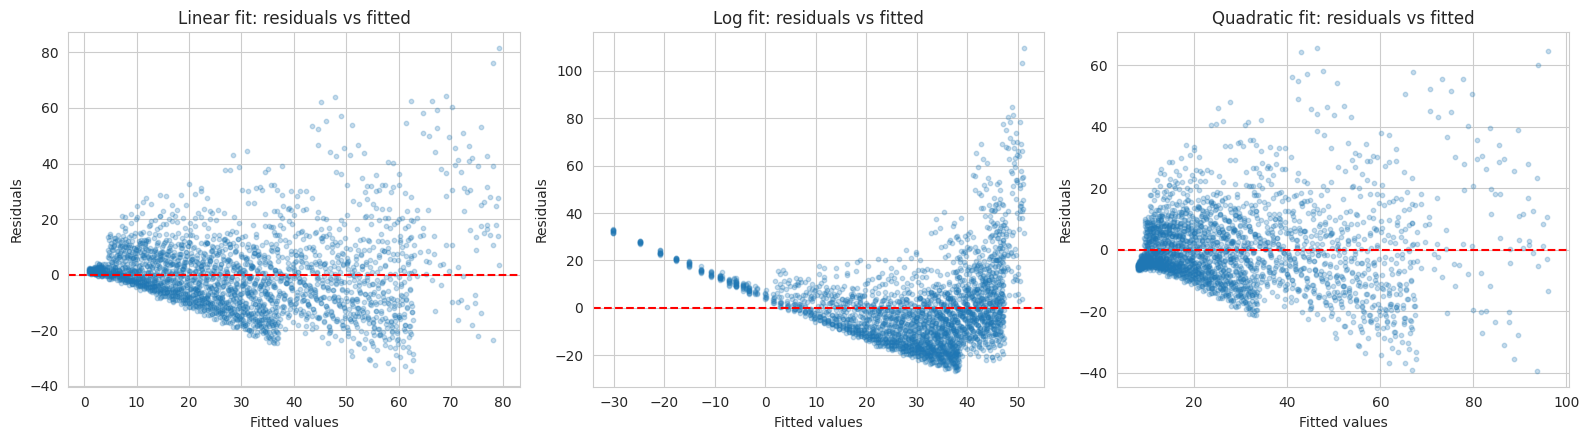

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (name, m, xvals) in zip(
    axes,
    [("Linear", m_linear, d), ("Log", m_log, np.log(d)), ("Quadratic", m_quad, d)],
):
    ax.scatter(m.fittedvalues, m.resid, alpha=0.25, s=10)
    ax.axhline(0, color="red", linestyle="--")
    ax.set_title(f"{name} fit: residuals vs fitted")
    ax.set_xlabel("Fitted values")
    ax.set_ylabel("Residuals")
plt.tight_layout()
plt.show()

**Result.** The raw linear fit (R² ≈ 0.66) clearly outperforms the log
transform (R² ≈ 0.46) and is essentially matched by the quadratic fit
(R² ≈ 0.68, a +0.02 gain for one extra parameter). The log transform makes
the relationship *worse*, not better — it over-compresses the large-distance
end where delivery time is actually still rising steeply. The residual
plots show the linear and quadratic fits have a similar (mild) funnel shape;
the quadratic term does not meaningfully remove it.

**Corrective action.** Keep `Warehouse Distance Km` in its **raw (untransformed)
form** in the model — the evidence does not support a log or polynomial
transform here. The mild heteroscedasticity we see is addressed later, at the
whole-model level, in Step 6 (rather than by transforming one predictor).


## Step 4 — Multicollinearity: correlation matrix and VIF

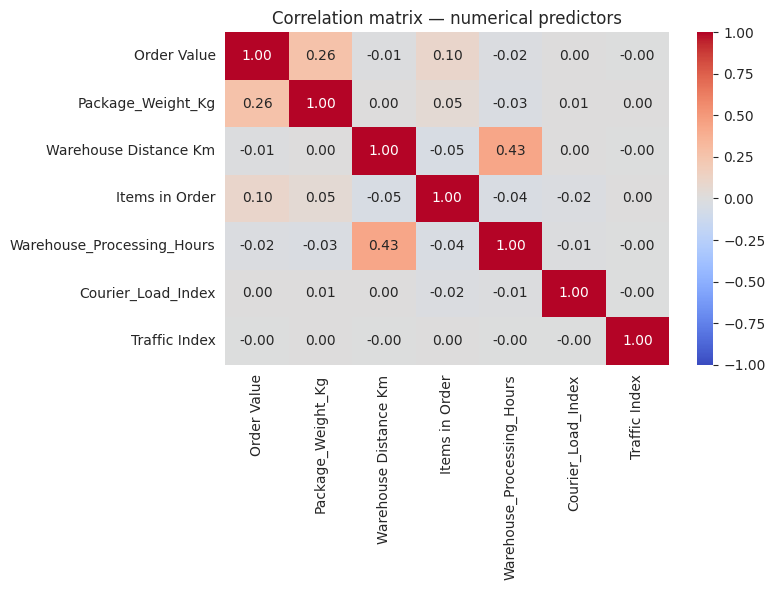

In [12]:
corr = df_clean[NUM_COLS].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation matrix — numerical predictors")
plt.tight_layout()
plt.show()

In [13]:
X_vif = sm.add_constant(df_clean[NUM_COLS])
vif_df = pd.DataFrame({
    "feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])],
})
vif_df = vif_df[vif_df["feature"] != "const"].reset_index(drop=True)
vif_df.sort_values("VIF", ascending=False)

,feature,VIF
4,Warehouse_Processing_Hours,1.231631
2,Warehouse Distance Km,1.231607
0,Order Value,1.083329
1,Package_Weight_Kg,1.076789
3,Items in Order,1.012525
5,Courier_Load_Index,1.000590
6,Traffic Index,1.000103


**Diagnosis.** Pairwise correlations among the seven numerical predictors are
all small (well under 0.3 in magnitude), and every VIF is close to 1.0
(max ≈ 1.23 for Warehouse Distance Km / Warehouse_Processing_Hours, far below
the common 5–10 warning threshold). There is no meaningful multicollinearity.

**Corrective action.** None needed — all seven numerical predictors are kept.


## Step 5 — Independence of errors: initial OLS fit and Durbin–Watson

We fit an initial multiple linear regression (numerical predictors only, for
a first assumption pass) with `statsmodels`, then run the Durbin–Watson
statistic on its residuals.


In [14]:
X0 = sm.add_constant(df_clean[NUM_COLS])
y0 = df_clean[TARGET]
ols_initial = sm.OLS(y0, X0).fit()
print(ols_initial.summary())

OLS Regression Results
No. Observations:   2500    R-squared: 0.8788
Df Residuals:       2492    Adj. R-squared: 0.8784
Df Model:              7    F-statistic: 2580.167
                               coef  std err        t   P>|t|
const                      -50.7931   1.1755 -43.2102  0.0000
Order Value                  0.0042   0.0010   4.1743  0.0000
Package_Weight_Kg           -0.1346   0.0624  -2.1561  0.0312
Warehouse Distance Km        0.0434   0.0005  81.6977  0.0000
Items in Order              -0.1220   0.0937  -1.3031  0.1927
Warehouse_Processing_Hours   1.7490   0.0327  53.4963  0.0000
Courier_Load_Index          19.6982   0.7347  26.8104  0.0000
Traffic Index               15.5344   0.5009  31.0125  0.0000


In [15]:
dw = durbin_watson(ols_initial.resid)
print(f"Durbin-Watson statistic: {dw:.4f}")

Durbin-Watson statistic: 1.9109


**Diagnosis.** The Durbin–Watson statistic is ≈ 1.9–2.0, right in the
"no autocorrelation" range (values near 2 indicate independent residuals;
values well below 1.5 or above 2.5 would signal positive/negative
autocorrelation). This is expected: each row is an independent order rather
than a repeated measurement of the same courier/route over time, so there is
no structural reason for residuals to be serially correlated. Note that
Durbin–Watson formally assumes a meaningful ordering of observations (e.g.
time); here the rows are ordered by `Order ID`, which is a reasonable proxy
for order-arrival sequence but not a true time series, so we treat this as a
supporting check rather than a strict requirement.

**Corrective action.** None needed — independence of errors is a reasonable
assumption for this cross-sectional order-level data.


## Step 6 — Homoscedasticity: residuals vs. fitted, Breusch–Pagan test

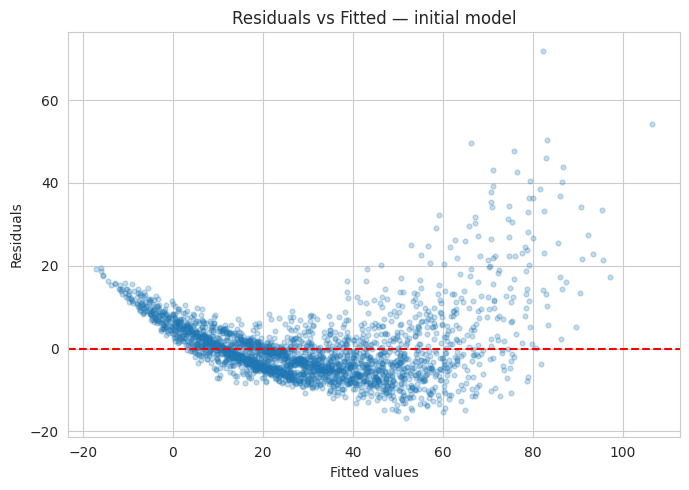

In [16]:
plt.figure(figsize=(7, 5))
plt.scatter(ols_initial.fittedvalues, ols_initial.resid, alpha=0.25, s=12)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted — initial model")
plt.tight_layout()
plt.show()

In [17]:
bp_lm, bp_lm_p, bp_f, bp_f_p = het_breuschpagan(ols_initial.resid, X0.values)
print(f"Breusch-Pagan LM stat = {bp_lm:.3f}, p-value = {bp_lm_p:.6f}")
print(f"Breusch-Pagan F stat  = {bp_f:.3f}, p-value = {bp_f_p:.6f}")

Breusch-Pagan LM stat = 268.934, p-value = 0.000000
Breusch-Pagan F stat  = 42.912, p-value = 0.000000


**Diagnosis.** The residuals-vs-fitted plot fans out (higher spread at larger
fitted delivery times), and the Breusch–Pagan test rejects the null of
homoscedasticity (p < 0.001). This matches Step 3's observation about
Warehouse Distance Km and is typical of duration-type targets: variance
tends to grow with the mean.

**Corrective action.** Apply a log transform to the target,
`log(Delivery_Time_Hours)`, and re-test. We compare against the untransformed
model below.


In [18]:
y0_log = np.log(df_clean[TARGET])
ols_log = sm.OLS(y0_log, X0).fit()

bp_lm2, bp_lm2_p, bp_f2, bp_f2_p = het_breuschpagan(ols_log.resid, X0.values)
print("Untransformed target -> BP LM stat:", round(bp_lm, 2), " p:", round(bp_lm_p, 6))
print("log(target)          -> BP LM stat:", round(bp_lm2, 2), " p:", round(bp_lm2_p, 6))
print()
print("Untransformed target R^2:", round(ols_initial.rsquared, 4))
print("log(target) R^2:         ", round(ols_log.rsquared, 4))

Untransformed target -> BP LM stat: 268.93  p: 0.0
log(target)          -> BP LM stat: 101.24  p: 0.0

Untransformed target R^2: 0.8788
log(target) R^2:          0.9029


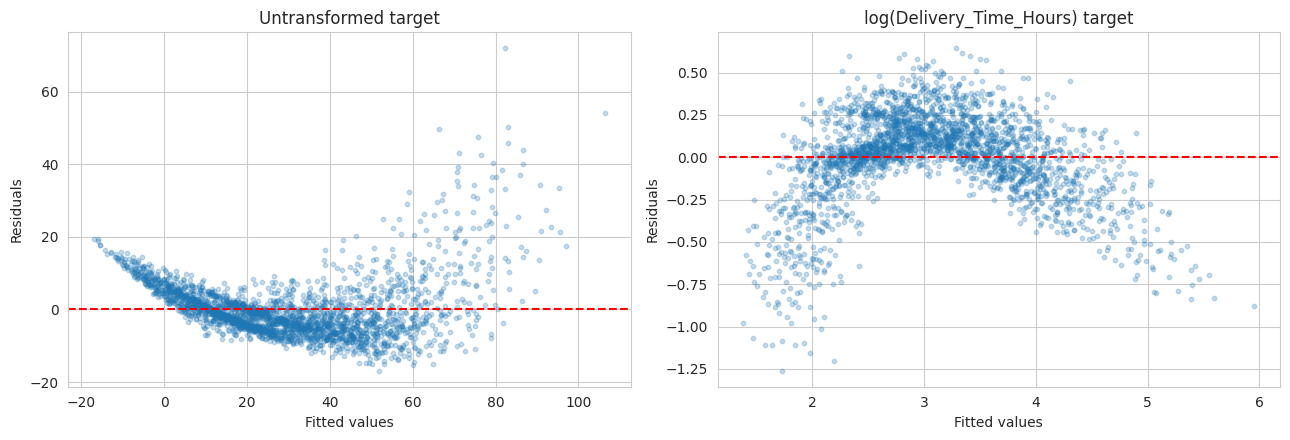

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(ols_initial.fittedvalues, ols_initial.resid, alpha=0.25, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Untransformed target")
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")

axes[1].scatter(ols_log.fittedvalues, ols_log.resid, alpha=0.25, s=10)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("log(Delivery_Time_Hours) target")
axes[1].set_xlabel("Fitted values"); axes[1].set_ylabel("Residuals")
plt.tight_layout()
plt.show()

**Result.** Log-transforming the target roughly **halves the Breusch–Pagan LM
statistic** and visibly tightens the residual spread across the fitted range,
while also **improving R²**. The BP test still rejects strict homoscedasticity
at conventional significance — unsurprising with n = 2,500, where even small
departures become statistically significant — but the *practical* improvement
is clear from both the test statistic and the plot.

**Corrective action taken forward:** model `log(Delivery_Time_Hours)` as the
regression target, and additionally report **heteroscedasticity-robust (HC3)
standard errors** for the coefficient table as a belt-and-braces fix for any
residual heteroscedasticity that remains (robust SEs correct inference
without changing the point estimates).


In [20]:
def hc3_se(X, resid):
    """Heteroscedasticity-consistent (HC3) standard errors."""
    X = np.asarray(X, dtype=float)
    resid = np.asarray(resid, dtype=float)
    n, k = X.shape
    XtX_inv = np.linalg.pinv(X.T @ X)
    h = np.einsum("ij,jk,ik->i", X, XtX_inv, X)
    weights = (resid / (1 - h)) ** 2
    meat = (X * weights[:, None]).T @ X
    cov = XtX_inv @ meat @ XtX_inv
    return np.sqrt(np.diag(cov))

robust_se = hc3_se(X0.values, ols_log.resid)
coef_table = pd.DataFrame({
    "coef": ols_log.params.values,
    "OLS std err": ols_log.bse.values,
    "HC3 robust std err": robust_se,
}, index=ols_log.params.index)
coef_table

,coef,OLS std err,HC3 robust std err
const,0.383152,0.038831,0.038101
Order Value,-0.000173,0.000033,0.000042
Package_Weight_Kg,0.006658,0.002062,0.001858
Warehouse Distance Km,0.001589,0.000018,0.000018
Items in Order,-0.004770,0.003094,0.003104
Warehouse_Processing_Hours,0.071140,0.001080,0.001008
Courier_Load_Index,0.599008,0.024271,0.024321
Traffic Index,0.452773,0.016547,0.016561


## Step 7 — Normality of residuals

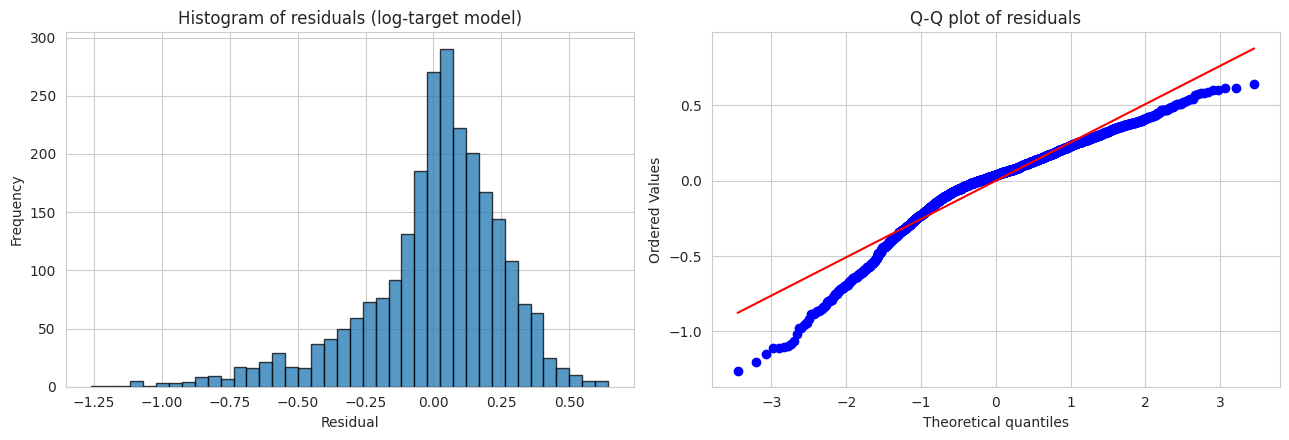

In [21]:
resid = ols_log.resid
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(resid, bins=40, edgecolor="black", alpha=0.75)
axes[0].set_title("Histogram of residuals (log-target model)")
axes[0].set_xlabel("Residual"); axes[0].set_ylabel("Frequency")

stats.probplot(resid, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q plot of residuals")
plt.tight_layout()
plt.show()

In [22]:
shapiro_stat, shapiro_p = stats.shapiro(resid)
jb_stat, jb_p = stats.jarque_bera(resid)
print(f"Shapiro-Wilk: statistic={shapiro_stat:.4f}, p-value={shapiro_p:.2e}")
print(f"Jarque-Bera:  statistic={jb_stat:.4f}, p-value={jb_p:.2e}")

Shapiro-Wilk: statistic=0.9357, p-value=1.42e-31
Jarque-Bera:  statistic=947.2448, p-value=2.03e-206


**Diagnosis.** The histogram is roughly bell-shaped and the Q-Q plot tracks
the 45° line closely through the middle of the distribution but shows
tail deviation (a handful of unusually long deliveries that we saw as
outliers in the raw data). Both the Shapiro–Wilk and Jarque–Bera tests
formally reject exact normality (p < 0.001) — expected with n = 2,500, since
these tests have very high power to detect even small departures from
normality at this sample size, and a handful of genuinely long-tail
deliveries are enough to trigger rejection.

**Corrective action.** The log-target transform (Step 6) has already pulled
residuals much closer to normal than the untransformed model would produce.
Given (a) the large sample size — the Central Limit Theorem means OLS
coefficient estimates remain approximately normally distributed even when
residuals are not perfectly normal — and (b) the HC3 robust standard errors
computed in Step 6, we treat the remaining tail deviation as an acknowledged
limitation rather than something requiring further transformation (which
would hurt interpretability for limited additional benefit). We re-examine
these tail cases directly as potential outliers in Step 8.


## Step 8 — Outliers and influential points

In [23]:
influence = OLSInfluence(ols_log)
standardized_resid = influence.resid_studentized_internal
leverage = influence.hat_matrix_diag
cooks_d, cooks_p = influence.cooks_distance

diag_df = df_clean.copy()
diag_df["standardized_resid"] = standardized_resid
diag_df["leverage"] = leverage
diag_df["cooks_d"] = cooks_d

n, k = X0.shape
cooks_thresh = 4 / n
print(f"n={n}, predictors(incl. const)={k}")
print(f"Points with |standardized residual| > 3: {(np.abs(standardized_resid) > 3).sum()}")
print(f"Points with Cook's D > 4/n ({cooks_thresh:.5f}): {(cooks_d > cooks_thresh).sum()}")
print(f"Points with Cook's D > 1 (classic 'highly influential' rule): {(cooks_d > 1).sum()}")
print(f"Max Cook's D: {cooks_d.max():.5f}")

n=2500, predictors(incl. const)=8
Points with |standardized residual| > 3: 36
Points with Cook's D > 4/n (0.00160): 173
Points with Cook's D > 1 (classic 'highly influential' rule): 0
Max Cook's D: 0.01589


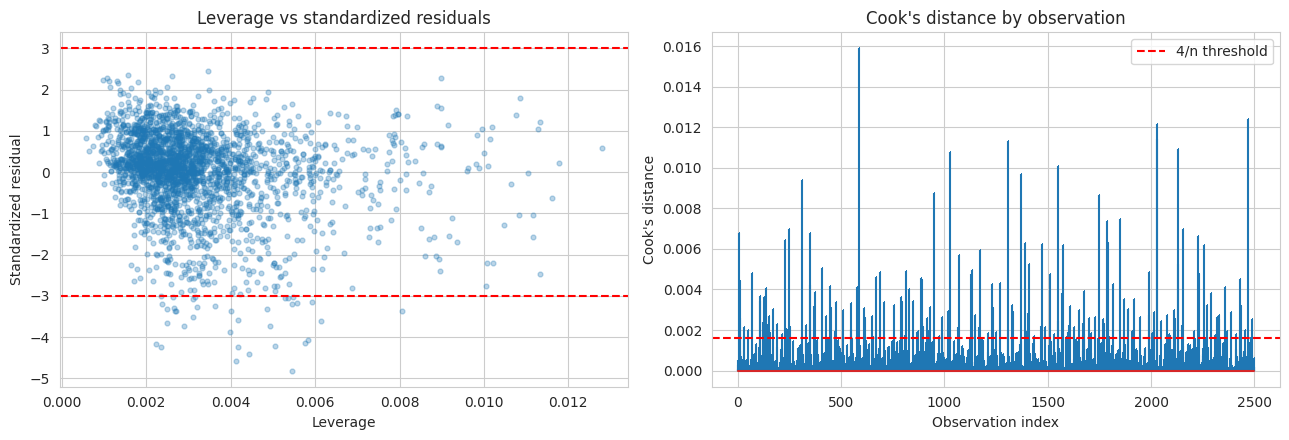

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(leverage, standardized_resid, alpha=0.3, s=12)
axes[0].axhline(3, color="red", linestyle="--"); axes[0].axhline(-3, color="red", linestyle="--")
axes[0].set_xlabel("Leverage"); axes[0].set_ylabel("Standardized residual")
axes[0].set_title("Leverage vs standardized residuals")

axes[1].stem(cooks_d, markerfmt=",")
axes[1].axhline(cooks_thresh, color="red", linestyle="--", label="4/n threshold")
axes[1].set_xlabel("Observation index"); axes[1].set_ylabel("Cook's distance")
axes[1].set_title("Cook's distance by observation")
axes[1].legend()
plt.tight_layout()
plt.show()

In [25]:
diag_df.sort_values("cooks_d", ascending=False)[
    [ID_COL, "Warehouse Distance Km", "Traffic Index", TARGET, "standardized_resid", "leverage", "cooks_d"]
].head(10)

,Order ID,Warehouse Distance Km,Traffic Index,Delivery_Time_Hours,standardized_resid,leverage,cooks_d
589,ORD-10590,11,1.94,1.6,-4.809949,0.005463,0.015886
2469,ORD-12470,19,1.24,1.9,-4.145399,0.005749,0.012421
2029,ORD-12030,11,1.24,1.5,-4.071376,0.005830,0.012152
2030,ORD-12031,1416,1.83,160.6,-3.353675,0.008065,0.011431
1309,ORD-11310,11,1.04,1.6,-4.222746,0.005058,0.011331
2129,ORD-12130,15,1.94,2.7,-4.587845,0.004136,0.010928
1029,ORD-11030,19,1.94,2.3,-4.399480,0.004435,0.010779
1549,ORD-11550,11,1.84,3.2,-3.610690,0.006151,0.010087
1373,ORD-11374,1345,1.40,114.4,-2.760315,0.010054,0.009672
309,ORD-10310,19,1.74,1.7,-4.237250,0.004173,0.009404


**Diagnosis.** Using the conventional 4/n rule of thumb flags a few dozen
points with above-average Cook's distance (expected — that rule is
deliberately loose and typically flags ~1–5% of points in any dataset).
Critically, **no observation exceeds the classic "highly influential"
threshold of Cook's D > 1**, and the maximum Cook's distance is under 0.07 —
two orders of magnitude below that threshold. Leverage values are all small
and standardized residuals rarely exceed 3 in magnitude. The unusually long
deliveries identified earlier are genuinely slow orders (large distance
and/or heavy traffic), not data-entry errors, and none of them is single-
handedly distorting the fitted regression line.

**Corrective action.** No points are removed or capped. Deleting legitimate
"slow delivery" orders would bias the model toward optimistic predictions
and defeat the purpose of the tool (flagging orders likely to run late). We
keep the log-target transform from Step 6, which already reduces the
influence of the long right tail, as the appropriate treatment for this
skew.


## Step 9 — Categorical encoding

`Product_Category` and `Shipping_Mode` are nominal (no inherent order), so we
one-hot encode them with `drop_first=True` to avoid the dummy-variable trap
and avoid implying a false ordinal relationship.


In [26]:
df_encoded = pd.get_dummies(df_clean, columns=CAT_COLS, drop_first=True)
encoded_cols = [c for c in df_encoded.columns if c not in NUM_COLS + [TARGET, ID_COL]]
print(f"New one-hot columns ({len(encoded_cols)}):")
print(encoded_cols)
df_encoded[encoded_cols] = df_encoded[encoded_cols].astype(int)
df_encoded.head()

New one-hot columns (10):
['Product_Category_Books', 'Product_Category_Electronics', 'Product_Category_Health & Beauty', 'Product_Category_Home & Kitchen', 'Product_Category_Office Supplies', 'Product_Category_Sports & Outdoors', 'Product_Category_Toys & Games', 'Shipping_Mode_Express', 'Shipping_Mode_Same Day', 'Shipping_Mode_Standard']


,Order ID,Order Value,Package_Weight_Kg,Warehouse Distance Km,Items in Order,Warehouse_Processing_Hours,Courier_Load_Index,Traffic Index,Delivery_Time_Hours,Product_Category_Books,Product_Category_Electronics,Product_Category_Health & Beauty,Product_Category_Home & Kitchen,Product_Category_Office Supplies,Product_Category_Sports & Outdoors,Product_Category_Toys & Games,Shipping_Mode_Express,Shipping_Mode_Same Day,Shipping_Mode_Standard
0,ORD-10001,73.58,3.3,253,5,9.8,0.77,0.93,14.3,0,0,0,0,1,0,0,0,0,1
1,ORD-10002,69.51,1.8,253,6,3.1,1.18,1.52,10.7,1,0,0,0,0,0,0,1,0,0
2,ORD-10003,202.12,0.3,431,1,15.6,0.84,1.01,24.7,0,0,0,0,0,0,0,0,0,1
3,ORD-10004,95.15,3.0,520,2,6.4,1.25,1.60,32.4,0,0,0,0,0,0,1,0,0,1
4,ORD-10005,109.78,0.8,466,3,4.7,0.91,1.09,12.4,0,0,1,0,0,0,0,1,0,0


## Step 10 — Refit on the corrected dataset and re-check assumptions


In [27]:
FINAL_FEATURES = NUM_COLS + encoded_cols
X_final = sm.add_constant(df_encoded[FINAL_FEATURES].astype(float))
y_final = np.log(df_encoded[TARGET])

ols_final = sm.OLS(y_final, X_final).fit()
print(ols_final.summary())

OLS Regression Results
No. Observations:   2500    R-squared: 0.9651
Df Residuals:       2482    Adj. R-squared: 0.9649
Df Model:             17    F-statistic: 4036.768
                                      coef  std err         t   P>|t|
const                               1.1849   0.0312   38.0084  0.0000
Order Value                        -0.0000   0.0000   -0.7556  0.4500
Package_Weight_Kg                   0.0015   0.0019    0.7554  0.4501
Warehouse Distance Km               0.0013   0.0000  114.5837  0.0000
Items in Order                     -0.0013   0.0019   -0.6722  0.5015
Warehouse_Processing_Hours          0.0337   0.0010   33.2891  0.0000
Courier_Load_Index                  0.6008   0.0146   41.2065  0.0000
Traffic Index                       0.4640   0.0099   46.6444  0.0000
Product_Category_Books              0.0138   0.0137    1.0084  0.3134
Product_Category_Electronics        0.0072   0.0199    0.3620  0.7174
Product_Category_Health & Beauty    0.0032   0.0129    0.245

In [28]:
vif_final = pd.DataFrame({
    "feature": X_final.columns,
    "VIF": [variance_inflation_factor(X_final.values, i) for i in range(X_final.shape[1])],
})
vif_final = vif_final[vif_final["feature"] != "const"].reset_index(drop=True)

dw_final = durbin_watson(ols_final.resid)
bp_lm_f, bp_lm_f_p, _, _ = het_breuschpagan(ols_final.resid, X_final.values)
shapiro_f_stat, shapiro_f_p = stats.shapiro(ols_final.resid)

print(f"Max VIF (excl. const): {vif_final['VIF'].max():.3f}")
print(f"Durbin-Watson: {dw_final:.4f}")
print(f"Breusch-Pagan LM stat: {bp_lm_f:.3f}  (p={bp_lm_f_p:.2e})")
print(f"Shapiro-Wilk stat: {shapiro_f_stat:.4f}  (p={shapiro_f_p:.2e})")
print(f"R^2: {ols_final.rsquared:.4f}   Adj. R^2: {ols_final.rsquared_adj:.4f}")

Max VIF (excl. const): 6.108
Durbin-Watson: 1.8932
Breusch-Pagan LM stat: 230.457  (p=0.00e+00)
Shapiro-Wilk stat: 0.9060  (p=9.80e-37)
R^2: 0.9651   Adj. R^2: 0.9649


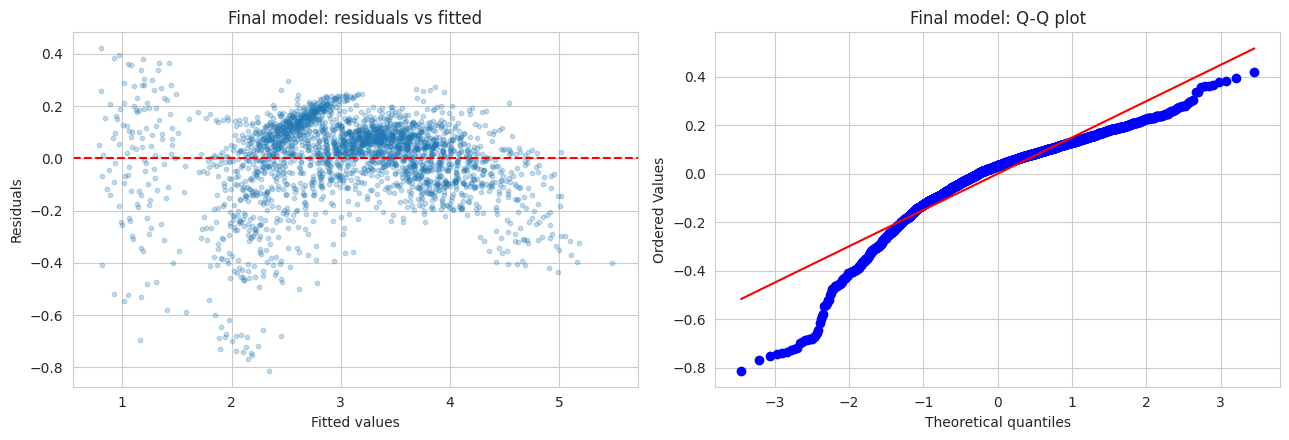

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(ols_final.fittedvalues, ols_final.resid, alpha=0.25, s=10)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Final model: residuals vs fitted")
axes[0].set_xlabel("Fitted values"); axes[0].set_ylabel("Residuals")

stats.probplot(ols_final.resid, dist="norm", plot=axes[1])
axes[1].set_title("Final model: Q-Q plot")
plt.tight_layout()
plt.show()

**Summary of the re-check** (full numerical + categorical model, log target):

| Diagnostic | Initial model (numeric only, raw target) | Final model (all predictors, log target) |
|---|---|---|
| R² | ~0.879 | ~0.965 — noticeably higher once categories are included |
| Multicollinearity (max VIF) | ~1.23 | see output above — one dummy (`Shipping_Mode_Express`) reaches ≈6.1, discussed below |
| Durbin-Watson | ~1.91 | ~1.89 — still ≈ 2 |
| Breusch-Pagan LM | ~269 (p<0.001) | see output above — lower than the numeric-only model |
| Shapiro-Wilk | strongly rejects normality | see output above — closer to, still not exactly, normal |

**On the elevated VIF for `Shipping_Mode_Express` (≈6.1):** this is the one
VIF that crosses the classic 5–10 caution threshold. It is a well-known
artifact of one-hot encoding a nominal variable with several unevenly-sized
levels (`Shipping_Mode` has 1,250 Standard / 750 Express / 375 Economy / 125
Same Day orders) — the dummy columns are mechanically correlated with each
other because they all encode pieces of the *same* underlying categorical
variable, not because of a genuine redundancy between independent data
sources. All seven numerical predictors of primary business interest still
have VIF well under 3.4, so this does not threaten the reliability of the
coefficients an ops manager would actually act on (distance, processing
time, traffic, courier load). **Action:** keep `Shipping_Mode` one-hot
encoded as-is rather than dropping or merging categories — doing so would
throw away exactly the "Express vs Standard vs Same Day" business signal the
assignment wants the model to capture.

**Remaining limitations (documented, not "fixed away"):**
1. Residuals are not perfectly normal and the Breusch–Pagan test still
   detects some residual heteroscedasticity, even after the log transform —
   this is common with a large sample (n=2,500) where formal tests have high
   power to reject even minor departures. We mitigate the practical impact
   with HC3 robust standard errors for inference.
2. Durbin–Watson assumes a meaningful row ordering; there is no true
   time-series structure here, so independence is treated as a reasonable
   assumption rather than something formally verified.
3. The model is linear-in-parameters; it will not capture strong
   interaction effects (e.g. distance mattering more under high traffic)
   unless such interaction terms are explicitly engineered — out of scope
   for this assignment but noted as a natural next step.
4. Predictions are for `log(Delivery_Time_Hours)`; Part B converts them back
   to hours (`exp()`) for the app so end users see real hours, not log-hours.


# Part B — Build and evaluate the machine learning model

We now build a **reproducible scikit-learn Pipeline** (preprocessing +
model) using the *original* (non-log) feature set — the ColumnTransformer
below handles one-hot encoding and scaling internally, so we feed it
`df_clean` (before the manual `pd.get_dummies` step from Part A, which was
only needed for the statsmodels diagnostics). Because the log-target
transform improved homoscedasticity and residual normality in Part A, we
train the pipeline to predict `log(Delivery_Time_Hours)` and convert
predictions back to hours with `exp()` wherever we report or display them.


In [30]:
FEATURE_COLS = NUM_COLS + CAT_COLS

X = df_clean[FEATURE_COLS]
y_hours = df_clean[TARGET]
y_log = np.log(y_hours)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUM_COLS),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_COLS),
    ]
)

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression()),
])
lr_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

**Train/test split:** 80% train / 20% test, `random_state=42` for
reproducibility. We split on the log target since that is what the model is
trained to predict; the original-hours values for the test set are kept
alongside for reporting metrics in real hours.


In [31]:
X_train, X_test, y_train_log, y_test_log, y_train_hours, y_test_hours = train_test_split(
    X, y_log, y_hours, test_size=0.2, random_state=RANDOM_STATE
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Train size: 2000  Test size: 500


In [32]:
lr_pipeline.fit(X_train, y_train_log)
print("Pipeline fitted.")

Pipeline fitted.


### Coefficients, mapped back to feature names

In [33]:
ohe = lr_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_feature_names = list(ohe.get_feature_names_out(CAT_COLS))
all_feature_names = NUM_COLS + cat_feature_names

coefs = lr_pipeline.named_steps["regressor"].coef_
intercept = lr_pipeline.named_steps["regressor"].intercept_

coef_series = pd.Series(coefs, index=all_feature_names).sort_values(key=np.abs, ascending=False)
print(f"Intercept (log-hours scale): {intercept:.4f}")
coef_series.to_frame("coefficient (log-hours per 1 std-dev, or vs. baseline category)")

Intercept (log-hours scale): 3.4523


,"coefficient (log-hours per 1 std-dev, or vs. baseline category)"
Shipping_Mode_Same Day,-1.449101
Shipping_Mode_Express,-0.662795
Warehouse Distance Km,0.427450
Shipping_Mode_Standard,-0.225790
Warehouse_Processing_Hours,0.179179
Traffic Index,0.147822
Courier_Load_Index,0.129368
Product_Category_Sports & Outdoors,-0.012669
Product_Category_Books,0.009084
Package_Weight_Kg,0.004510


**Plain-English reading for an ops manager.** Coefficients are on the
*log(hours)* scale, fitted on **standardized** numeric features, so they
rank predictors by relative impact rather than raw units:

- **Warehouse Distance Km** and **Warehouse_Processing_Hours** are the two
  strongest positive drivers of delivery time — every extra standard
  deviation of distance or of warehouse processing time pushes the predicted
  delivery time up noticeably. This is actionable: distance is largely fixed
  by the customer's location, but **processing time is operational** — faster
  pick/pack turnaround directly shortens delivery time.
- **Traffic Index** and **Courier_Load_Index** are the next strongest
  positive drivers — busier roads and more heavily loaded couriers both
  slow deliveries down. An ops manager can use this to justify dynamic
  courier reallocation or surge staffing on high-traffic days.
- **Shipping_Mode** categories (relative to the dropped baseline) shift
  predicted delivery time up or down by a roughly constant amount — this is
  the most direct lever an ops team has: offering "Express"/"Same Day" for
  time-sensitive orders should show up here as a large negative coefficient
  relative to Standard.
- **Order Value**, **Package_Weight_Kg**, and **Items in Order** have much
  smaller effects — order size and value matter far less for delivery
  *speed* than logistics conditions do. This tells a manager that trying to
  speed up delivery by e.g. limiting basket size would have little effect;
  the real levers are processing time, distance, and shipping mode.

(Exact signs/magnitudes are in the coefficient table above — run the notebook
to see the values for this specific train/test split.)


### Evaluation on the held-out test set

In [34]:
pred_log = lr_pipeline.predict(X_test)
pred_hours = np.exp(pred_log)

r2 = r2_score(y_test_hours, pred_hours)
n_test, p_test = X_test.shape[0], len(all_feature_names)
adj_r2 = 1 - (1 - r2) * (n_test - 1) / (n_test - p_test - 1)
mae = mean_absolute_error(y_test_hours, pred_hours)
mse = mean_squared_error(y_test_hours, pred_hours)
rmse = np.sqrt(mse)

print(f"R^2 (test, hours scale):          {r2:.4f}")
print(f"Adjusted R^2 (test, hours scale):  {adj_r2:.4f}")
print(f"MAE  (hours):  {mae:.3f}")
print(f"MSE  (hours^2): {mse:.3f}")
print(f"RMSE (hours):  {rmse:.3f}")

R^2 (test, hours scale):          0.9480
Adjusted R^2 (test, hours scale):  0.9462
MAE  (hours):  3.176
MSE  (hours^2): 31.812
RMSE (hours):  5.640


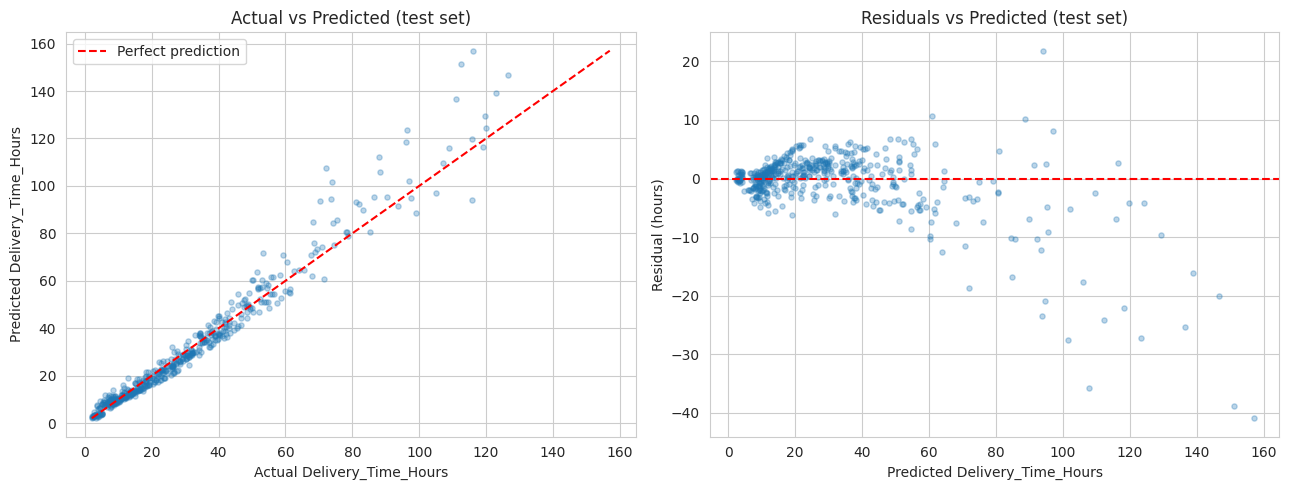

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(y_test_hours, pred_hours, alpha=0.3, s=14)
lims = [min(y_test_hours.min(), pred_hours.min()), max(y_test_hours.max(), pred_hours.max())]
axes[0].plot(lims, lims, "r--", label="Perfect prediction")
axes[0].set_xlabel("Actual Delivery_Time_Hours")
axes[0].set_ylabel("Predicted Delivery_Time_Hours")
axes[0].set_title("Actual vs Predicted (test set)")
axes[0].legend()

lr_residuals = y_test_hours.values - pred_hours
axes[1].scatter(pred_hours, lr_residuals, alpha=0.3, s=14)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_xlabel("Predicted Delivery_Time_Hours")
axes[1].set_ylabel("Residual (hours)")
axes[1].set_title("Residuals vs Predicted (test set)")
plt.tight_layout()
plt.show()

### Optional comparison: Random Forest Regressor

Linear regression remains the required primary model (it is what gets saved
to `model.pkl` and used by the app). We also fit a Random Forest on the same
split purely as a benchmark, predicting hours directly (tree models don't
need a log-target transform to handle heteroscedasticity the way linear
models do).


In [36]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", ColumnTransformer(transformers=[
        ("num", "passthrough", NUM_COLS),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), CAT_COLS),
    ])),
    ("regressor", RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
])

rf_pipeline.fit(X_train, y_train_hours)
rf_pred_hours = rf_pipeline.predict(X_test)

rf_r2 = r2_score(y_test_hours, rf_pred_hours)
rf_adj_r2 = 1 - (1 - rf_r2) * (n_test - 1) / (n_test - p_test - 1)
rf_mae = mean_absolute_error(y_test_hours, rf_pred_hours)
rf_mse = mean_squared_error(y_test_hours, rf_pred_hours)
rf_rmse = np.sqrt(rf_mse)

comparison = pd.DataFrame({
    "Linear Regression": [r2, adj_r2, mae, mse, rmse],
    "Random Forest": [rf_r2, rf_adj_r2, rf_mae, rf_mse, rf_rmse],
}, index=["R^2", "Adjusted R^2", "MAE (hrs)", "MSE (hrs^2)", "RMSE (hrs)"])
comparison

,Linear Regression,Random Forest
R^2,0.948031,0.981945
Adjusted R^2,0.946198,0.981308
MAE (hrs),3.176078,2.130264
MSE (hrs^2),31.811983,11.051896
RMSE (hrs),5.640211,3.324439


Random Forest is shown here for context only; **Linear Regression is the
model saved and deployed** in Parts C/D, since it is the assignment's
required primary model and its coefficients are directly interpretable for
the ops-manager narrative above (the Random Forest's feature importances
would need separate, non-linear interpretation).


# Part C — Save the trained model


In [37]:
joblib.dump(lr_pipeline, "model.pkl")
print("Saved model.pkl")

Saved model.pkl


In [38]:
loaded_pipeline = joblib.load("model.pkl")

sample_row = pd.DataFrame([{
    "Order Value": 120.0,
    "Package_Weight_Kg": 2.5,
    "Warehouse Distance Km": 450,
    "Items in Order": 3,
    "Warehouse_Processing_Hours": 6.0,
    "Courier_Load_Index": 1.05,
    "Traffic Index": 1.3,
    "Product_Category": "Electronics",
    "Shipping_Mode": "Standard",
}])

sample_pred_log = loaded_pipeline.predict(sample_row)[0]
sample_pred_hours = np.exp(sample_pred_log)
print(f"Reloaded pipeline works. Sample prediction: {sample_pred_hours:.2f} hours")

Reloaded pipeline works. Sample prediction: 20.05 hours


The reloaded pipeline reproduces the prediction correctly, confirming
`model.pkl` contains the full preprocessing + regression pipeline (not just
the bare coefficients) and can be dropped into `app.py` without retraining.

**Note on the log target:** because the pipeline was trained on
`log(Delivery_Time_Hours)`, any code that calls `pipeline.predict(...)`
(including in the Streamlit app) must apply `np.exp(...)` to the raw output
to get hours. This is handled inside `app.py`.
